In [2]:
import sys
sys.path.append("..")

In [3]:
import torch
from torch import optim, nn
from utils.dataset import get_emnist_dataloaders, get_emnist_gpu_transform
from utils.trainer import fit, evaluate_classification
from utils.visualizer import Visualizer
from utils.callbacks import ModelCheckpoint
from models import CharacterClassifierResNet

In [10]:
train_loader, val_loader, test_laoder = get_emnist_dataloaders(batch_size=2048, num_workers=2, split="byclass")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
aug = get_emnist_gpu_transform()

[EMNIST] Loading 'bymerge' split into RAM...
[EMNIST] split='bymerge' | train=628,139  val=69,793  test=116,323  workers=2


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
model = CharacterClassifierResNet(num_classes=62)
model = model.to(device)
print(model)
print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

CharacterClassifierResNet(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (block1): BasicBlock(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (skip): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2))
  )
  (block2): BasicBlock(
    (conv): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1),

In [7]:
EPOCHS = 30
optimizer = optim.Adam(model.parameters())
scheduler = optim.lr_scheduler.OneCycleLR(
    pct_start=0.3,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    optimizer=optimizer,
    max_lr=1e-3,
    div_factor = 25.0,
    final_div_factor = 1e4,
)
criterion = nn.CrossEntropyLoss()
NAME = "classifier_resent_byclass_s"
checkpoint = ModelCheckpoint(
    model, verbose=False,
    checkpoint_path=f"../checkpoint/{NAME}_latest.pth",
    best_model_path=f"../checkpoint/{NAME}_best.pth",
)
scaler = torch.amp.GradScaler('cuda')

In [7]:
history = fit(
    model, train_loader, val_loader,
    criterion, optimizer, device,
    scheduler=scheduler, scaler=scaler,
    epochs=EPOCHS, gpu_augment=aug,
    verbose=True, log=True, model_label=NAME,
    step_scheduler_per_batch=True, checkpoint=checkpoint,
)

Training with bf16 autocast | Task: classification | Epochs: 30
[RunLogger] ▶  Run 'classifier_resent_byclass_s_20260702_222509' started — saving to 'C:\OD-From-Scratch\logs\CharacterClassifierResNet\classifier_resent_byclass_s_20260702_222509.json'
[RunLogger] Epoch   1 | train_loss=3.0739  val_loss=1.7663  val_acc=55.5299%  lr=6.90e-05  ⏱ 11.1s  ★ NEW BEST
[RunLogger] Epoch   2 | train_loss=1.5549  val_loss=0.9893  val_acc=69.3193%  lr=1.52e-04  ⏱ 8.3s  ★ NEW BEST
[RunLogger] Epoch   3 | train_loss=0.8928  val_loss=0.5706  val_acc=80.4092%  lr=2.80e-04  ⏱ 8.3s  ★ NEW BEST
[RunLogger] Epoch   4 | train_loss=0.6571  val_loss=0.4992  val_acc=82.4295%  lr=4.37e-04  ⏱ 8.3s  ★ NEW BEST
[RunLogger] Epoch   5 | train_loss=0.5537  val_loss=0.5168  val_acc=82.2389%  lr=6.04e-04  ⏱ 8.3s
[RunLogger] Epoch   6 | train_loss=0.4917  val_loss=0.4713  val_acc=83.7534%  lr=7.60e-04  ⏱ 8.3s  ★ NEW BEST
[RunLogger] Epoch   7 | train_loss=0.4623  val_loss=0.5000  val_acc=82.2747%  lr=8.88e-04  ⏱ 8.3s
[Ru

In [8]:
checkpoint.restore_best_weights()

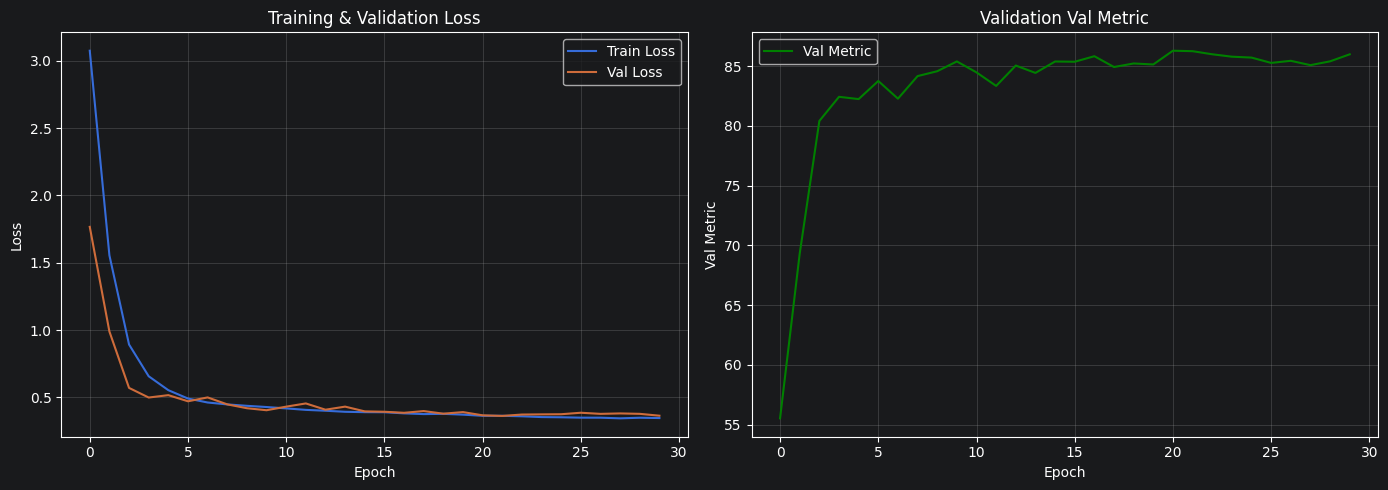

In [9]:
Visualizer.visualize_training_curves(history['train_loss'], history['val_loss'], history['val_metric'])

In [11]:
test_loss, test_acc = evaluate_classification(model, test_laoder, criterion, device, print_per_class_accuracy=True)
print(f"Test loss: {test_loss:.3f}, Test accuracy: {test_acc:.3f}")

Per-class accuracy:
  0: 71.09% (4084/5745)
  1: 78.64% (5033/6400)
  2: 98.42% (5674/5765)
  3: 99.54% (5800/5827)
  4: 98.29% (5404/5498)
  5: 88.25% (4700/5326)
  6: 97.63% (5650/5787)
  7: 99.57% (5848/5873)
  8: 98.36% (5562/5655)
  9: 98.97% (5593/5651)
  A: 98.77% (1045/1058)
  B: 97.70% (637/652)
  C: 97.59% (2104/2156)
  D: 86.53% (636/735)
  E: 93.60% (805/860)
  F: 97.97% (1493/1524)
  G: 82.09% (353/430)
  H: 92.01% (530/576)
  I: 57.19% (1380/2413)
  J: 67.87% (619/912)
  K: 38.81% (314/809)
  L: 22.87% (768/3358)
  M: 99.60% (1976/1984)
  N: 98.89% (1336/1351)
  O: 69.06% (3239/4690)
  P: 90.45% (1639/1812)
  Q: 91.81% (381/415)
  R: 97.13% (811/835)
  S: 97.82% (3814/3899)
  T: 91.41% (1490/1630)
  U: 94.15% (2380/2528)
  V: 70.65% (864/1223)
  W: 40.89% (516/1262)
  X: 30.10% (270/897)
  Y: 69.62% (832/1195)
  Z: 24.76% (229/925)
  a: 92.93% (1550/1668)
  b: 92.92% (866/932)
  d: 0.00% (0/1708)
  e: 0.02% (1/4066)
  f: 0.00% (0/426)
  g: 0.00% (0/583)
  h: 0.00% (0/1535